# Lesson 13.2 - Robustness, Adversarial ML & AI Security (toy adversarial demo)

This notebook demonstrates how small input perturbations can degrade classifier performance and how to reason about threat models in practice.
        


## Objectives

- Train a baseline classifier on an image-like dataset.
- Implement an FGSM-like perturbation for multinomial logistic regression.
- Measure attack success and discuss defense patterns.
        


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)
        


## Train Baseline Model


In [2]:
digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_s, y_train)

clean_acc = accuracy_score(y_test, clf.predict(X_test_s))
clean_acc
        


0.9777777777777777

## FGSM-like Attack for Multinomial Logistic Regression

For softmax regression with weights $W$ and logits $z = Wx + b$, the gradient of cross-entropy w.r.t. input is:

$
abla_x L = W^T (p - y_{onehot})$

We add perturbation: $x_{adv} = x + \epsilon \cdot sign(
abla_x L)$.
        


In [3]:
def softmax(logits: np.ndarray) -> np.ndarray:
    shift = logits - np.max(logits)
    exp = np.exp(shift)
    return exp / exp.sum()


def fgsm_like_attack_lr(x: np.ndarray, y_true: int, model: LogisticRegression, epsilon: float) -> np.ndarray:
    W = model.coef_            # shape: [n_classes, n_features]
    b = model.intercept_       # shape: [n_classes]

    logits = W @ x + b
    p = softmax(logits)

    y_onehot = np.zeros_like(p)
    y_onehot[y_true] = 1.0

    grad_x = W.T @ (p - y_onehot)
    x_adv = x + epsilon * np.sign(grad_x)
    return x_adv


feature_min = X_train_s.min(axis=0)
feature_max = X_train_s.max(axis=0)

def clip_features(x: np.ndarray) -> np.ndarray:
    return np.clip(x, feature_min, feature_max)
        


## Evaluate Attack Across Epsilon Values


In [4]:
def evaluate_attack(epsilon: float):
    X_adv = []
    for i in range(len(X_test_s)):
        x = X_test_s[i]
        x_adv = fgsm_like_attack_lr(x, int(y_test[i]), clf, epsilon=epsilon)
        X_adv.append(clip_features(x_adv))
    X_adv = np.array(X_adv)

    pred_clean = clf.predict(X_test_s)
    pred_adv = clf.predict(X_adv)

    clean = accuracy_score(y_test, pred_clean)
    adv = accuracy_score(y_test, pred_adv)
    asr = np.mean(pred_clean != pred_adv)
    return clean, adv, asr, X_adv

results = []
all_adv = {}
for eps in [0.0, 0.05, 0.10, 0.20, 0.30]:
    clean, adv, asr, X_adv = evaluate_attack(eps)
    results.append({"epsilon": eps, "clean_accuracy": clean, "adversarial_accuracy": adv, "attack_success_rate": asr})
    all_adv[eps] = X_adv

results_df = pd.DataFrame(results)
results_df
        


,epsilon,clean_accuracy,adversarial_accuracy,attack_success_rate
0,0.00,0.977778,0.977778,0.000000
1,0.05,0.977778,0.937778,0.040000
2,0.10,0.977778,0.888889,0.088889
3,0.20,0.977778,0.720000,0.257778
4,0.30,0.977778,0.493333,0.484444


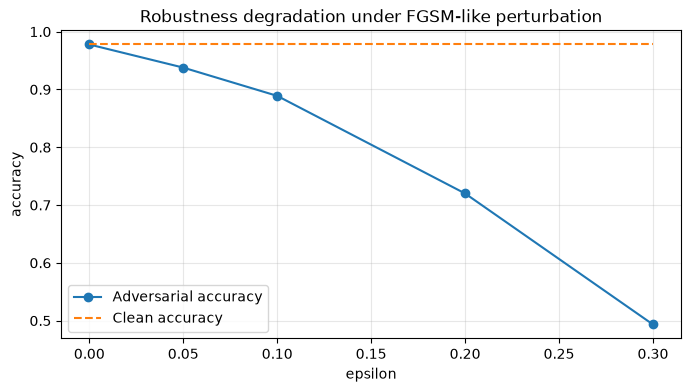

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(results_df["epsilon"], results_df["adversarial_accuracy"], marker="o", label="Adversarial accuracy")
plt.plot(results_df["epsilon"], results_df["clean_accuracy"], linestyle="--", label="Clean accuracy")
plt.xlabel("epsilon")
plt.ylabel("accuracy")
plt.title("Robustness degradation under FGSM-like perturbation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
        


## Visualize Original vs Perturbed Samples


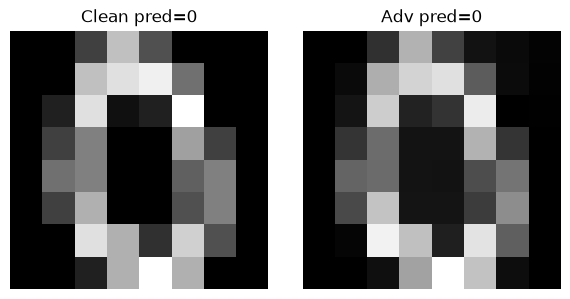

In [6]:
idx_candidates = np.where(clf.predict(X_test_s) == y_test)[0]
idx = int(idx_candidates[0])
epsilon = 0.20

x_clean = X_test_s[idx]
x_adv = all_adv[epsilon][idx]

y_hat_clean = int(clf.predict(x_clean.reshape(1, -1))[0])
y_hat_adv = int(clf.predict(x_adv.reshape(1, -1))[0])

def to_img(x_scaled):
    # inverse-transform back to original digit pixel range for plotting
    x_orig = scaler.inverse_transform(x_scaled.reshape(1, -1))[0]
    return np.clip(x_orig.reshape(8, 8), 0, 16)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(to_img(x_clean), cmap="gray")
axes[0].set_title(f"Clean pred={y_hat_clean}")
axes[0].axis("off")

axes[1].imshow(to_img(x_adv), cmap="gray")
axes[1].set_title(f"Adv pred={y_hat_adv}")
axes[1].axis("off")

plt.tight_layout()
plt.show()
        


## Connect to Theory

- The attack assumes a `white-box` setting because model coefficients are used.
- Attack success rises with perturbation budget $\epsilon$.
- Even simple models can be vulnerable, reinforcing need for robust evaluation in deployment pipelines.
        


## Safety & Security Case Studies & Exceptions

### Case Study A: Vision Model in Access Control
A building security classifier was accurate in QA but weak under adversarial patches. Team added confidence gating and manual fallback for uncertain cases.

### Case Study B: Feedback Poisoning
A retraining pipeline consumed untrusted user labels. Attackers skewed labels to degrade quality. Mitigation used trust scoring and delayed promotion.

### Exception Pattern
For non-critical internal analytics models, heavy adversarial testing can be right-sized, but API abuse protections and logging should still be present.
        


## Interview Questions & Answers

1. **Q:** What is an evasion attack?  
   **A:** An inference-time perturbation that causes incorrect predictions.
2. **Q:** White-box vs black-box?  
   **A:** White-box attackers know internals; black-box attackers only query the model.
3. **Q:** What is FGSM intuition?  
   **A:** Move input in gradient-sign direction that maximally increases loss within a small budget.
4. **Q:** Why can tiny perturbations work?  
   **A:** High-dimensional decision boundaries can be locally sensitive.
5. **Q:** What is poisoning?  
   **A:** Injecting malicious training data to change learned behavior.
6. **Q:** What is model extraction risk?  
   **A:** API queries can reconstruct behavior and enable stronger attacks.
7. **Q:** How do you defend in practice?  
   **A:** Layered controls: robust training, monitoring, access limits, anomaly detection.
8. **Q:** What metric indicates attack impact?  
   **A:** Robust accuracy and attack success rate under defined threat settings.
9. **Q:** Why include threat model in reports?  
   **A:** Security claims are meaningful only relative to assumptions.
10. **Q:** Is one defense enough?  
    **A:** No, attackers adapt; defense-in-depth is required.
11. **Q:** Where does AI security fit in MLOps?  
    **A:** In pipeline controls, release gating, monitoring, and incident response.
        
